# CSCI2000U - Assignment 1
## Spotify Streaming Analysis
**Name:** Thanh Thuy Nguyen
**StudentID:** 101019881

## 1. Introduction

Music streaming services have grown to be important data sources for comprehending the consumption of digital media in recent years.  Metadata like daily rankings, cumulative stream counts, and chart performance metrics are produced by each streamed track.  These data make it possible to look at more general trends in listening habits and the elements that influence a song's sustained popularity.

I chose a single CSV dataset with aggregated statistics for songs that have appeared on the ranking charts of a significant streaming platform for this assignment.  The track's current ranking position, the number of days since its release, the number of times it placed in the top 10, its best (peak) position, the number of times that peak was reached, the number of streams linked to that peak, and the total accumulated streams are all included in each record, which corresponds to a distinct artist–song pair.

For this project, I wanted to investigate general patterns in streaming performance and find connections between chart behavior and total stream counts.  I specifically sought to answer the following queries:
- Which performers have the most streams overall?
- How closely does a song's age (number of days since release) correlate with its overall streaming volume?
- Do songs that are in the top 10 for a longer period of time typically receive more streams overall?
- Do peak streams and total streams have a quantifiable linear relationship?


I used a typical data science workflow, which included data loading, cleaning, exploratory data analysis, grouped summary statistics, visualization, and a basic linear regression model, to look into these questions.  Instead of creating predictive or causal models, all of the analyses in this assignment were descriptive in nature and meant to describe broad trends in streaming outcomes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# For notebook
%matplotlib inline

In [2]:
df = pd.read_csv("Spotify_final_dataset.csv")

df.head()

,Position,Artist Name,Song Name,Days,Top 10 (xTimes),Peak Position,Peak Position (xTimes),Peak Streams,Total Streams
0,1,Post Malone,Sunflower SpiderMan: Into the SpiderVerse,1506,302.0,1,(x29),2118242,883369738
1,2,Juice WRLD,Lucid Dreams,1673,178.0,1,(x20),2127668,864832399
2,3,Lil Uzi Vert,XO TOUR Llif3,1853,212.0,1,(x4),1660502,781153024
3,4,J. Cole,No Role Modelz,2547,6.0,7,0,659366,734857487
4,5,Post Malone,rockstar,1223,186.0,1,(x124),2905678,718865961


In [3]:
# Strip whitespace and rename columns
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns={
    "Position": "position",
    "Artist Name": "artist",
    "Song Name": "song",
    "Days": "days",
    "Top 10 (xTimes)": "top10_times",
    "Peak Position": "peak_position",
    "Peak Position (xTimes)": "peak_times",
    "Peak Streams": "peak_streams",
    "Total Streams": "total_streams"
})

# Convert numeric columns
numeric_cols = ["position", "days", "top10_times", "peak_position", 
                "peak_streams", "total_streams"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Parse peak_times "(x29)" → 29
df["peak_times"] = (
    df["peak_times"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
)
df["peak_times"] = pd.to_numeric(df["peak_times"], errors="coerce")

# Data types
df.dtypes

position           int64
artist            object
song              object
days               int64
top10_times      float64
peak_position      int64
peak_times         int64
peak_streams       int64
total_streams      int64
dtype: object

In [4]:
# Missing values table
missing_counts = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

missing_table

,missing_count,missing_percent
position,0,0.00
artist,0,0.00
song,4,0.04
days,0,0.00
top10_times,0,0.00
peak_position,0,0.00
peak_times,0,0.00
peak_streams,0,0.00
total_streams,0,0.00


In [5]:
# Summary statistics
cols_of_interest = [
    "position", "days", "top10_times", 
    "peak_position", "peak_times", 
    "peak_streams", "total_streams"
]

df[cols_of_interest].describe().T

,count,mean,std,min,25%,50%,75%,max
position,11084.0,5.542500e+03,3.199820e+03,1.0,2771.75,5542.5,8313.25,11084.0
days,11084.0,5.336693e+01,1.297509e+02,1.0,2.00,7.0,39.00,2547.0
top10_times,11084.0,2.713641e+00,1.560413e+01,0.0,0.00,0.0,0.00,302.0
peak_position,11084.0,8.307010e+01,5.893205e+01,1.0,29.00,75.0,132.00,200.0
peak_times,11084.0,3.869542e-01,3.604104e+00,0.0,0.00,0.0,0.00,124.0
peak_streams,11084.0,5.529469e+05,6.282936e+05,44323.0,243159.50,350588.5,596338.25,7786096.0
total_streams,11084.0,1.830891e+07,5.219383e+07,44323.0,382427.25,1704876.5,10783331.50,883369738.0


In [6]:
# Clean subset
df_clean = df.dropna(subset=["peak_streams", "total_streams", "days", "top10_times"])
df_clean.shape

(11084, 9)

## 2. Exploratory Data Analysis

In this section, I examine basic properties of the dataset: data types, missing values, and 
summary statistics. I also create a few visualisations to better understand distributions 
and relationships between key variables such as days since release, time spent in the top 10, 
peak streams, and total streams.

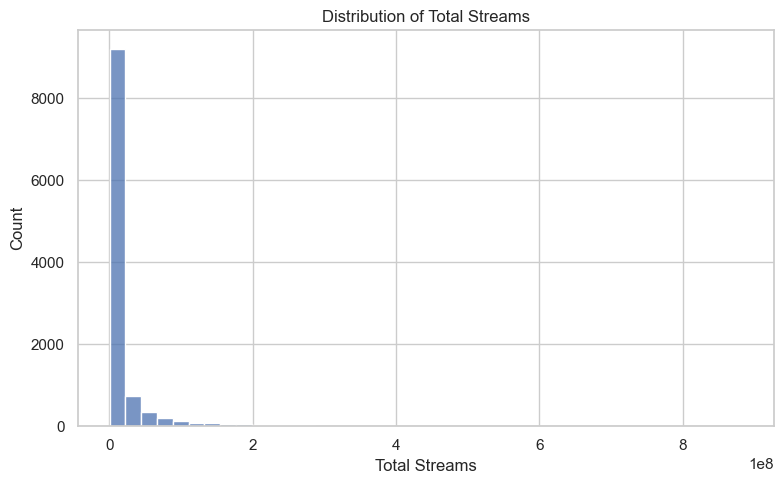

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["total_streams"], bins=40)
plt.title("Distribution of Total Streams")
plt.xlabel("Total Streams")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

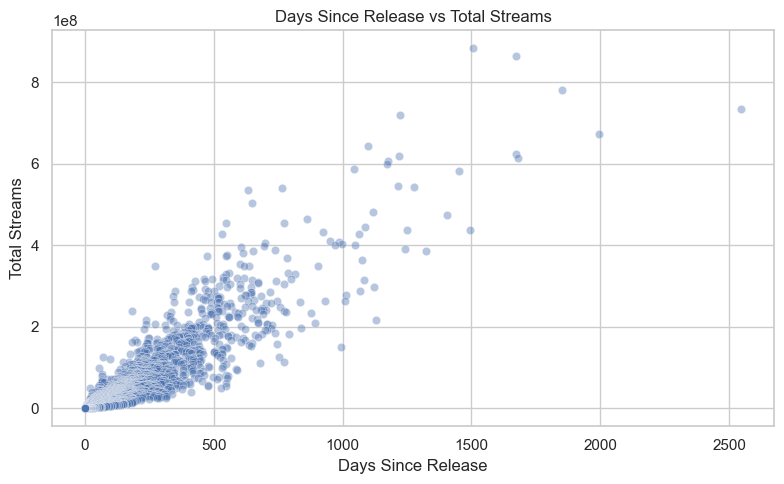

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="days", y="total_streams", alpha=0.4)
plt.title("Days Since Release vs Total Streams")
plt.xlabel("Days Since Release")
plt.ylabel("Total Streams")
plt.tight_layout()
plt.show()

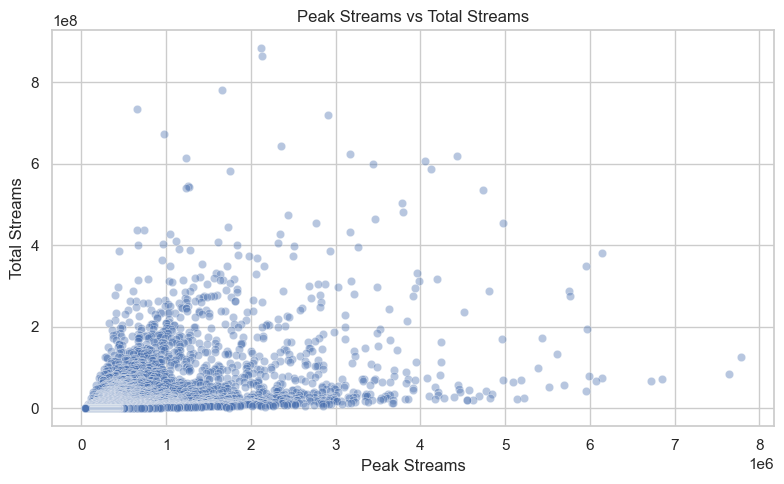

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="peak_streams", y="total_streams", alpha=0.4)
plt.title("Peak Streams vs Total Streams")
plt.xlabel("Peak Streams")
plt.ylabel("Total Streams")
plt.tight_layout()
plt.show()

In [10]:
def peak_bucket(pos):
    if pd.isna(pos):
        return "Unknown"
    if pos == 1:
        return "1"
    elif 2 <= pos <= 5:
        return "2–5"
    elif 6 <= pos <= 10:
        return "6–10"
    else:
        return ">10"
    
df_clean = df_clean.copy()
df_clean["peak_bucket"] = df_clean["peak_position"].apply(peak_bucket)


df_clean["peak_bucket"].value_counts()

peak_bucket
>10     9854
2–5      526
6–10     514
1        190
Name: count, dtype: int64

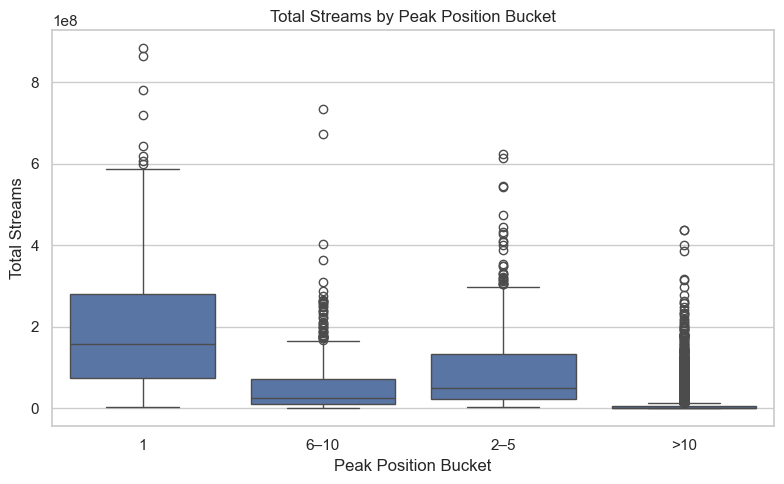

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="peak_bucket", y="total_streams")
plt.title("Total Streams by Peak Position Bucket")
plt.xlabel("Peak Position Bucket")
plt.ylabel("Total Streams")
plt.tight_layout()
plt.show()

## 3. Grouped Analyses

Next, I construct grouped summary tables using Pandas. The first table aggregates total 
streams by artist, and the second uses a multi-key grouping by both artist and peak 
position to explore how chart peaks relate to streaming outcomes.

In [12]:
artist_streams = (
    df_clean
    .groupby("artist", as_index=False)["total_streams"]
    .sum()
    .sort_values("total_streams", ascending=False)
)

top10_artists = artist_streams.head(10)
top10_artists

,artist,total_streams
394,Drake,9228928893
1136,Post Malone,7400199432
708,Juice WRLD,4857996474
1431,The Weeknd,4267010379
1537,XXXTENTACION,3689771047
1375,Taylor Swift,3222972346
88,Ariana Grande,3168771349
167,Billie Eilish,3119498389
834,Lil Uzi Vert,2915127161
129,Bad Bunny,2789775409


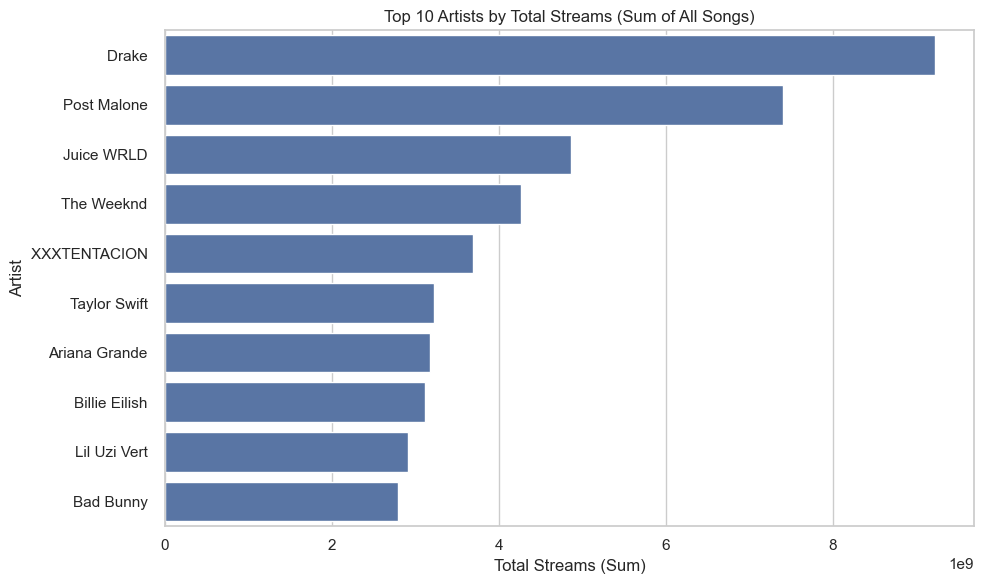

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_artists, x="total_streams", y="artist")
plt.title("Top 10 Artists by Total Streams (Sum of All Songs)")
plt.xlabel("Total Streams (Sum)")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

In [14]:
artist_peak_summary = (
    df_clean
    .groupby(["artist", "peak_position"], as_index=False)
    .agg({
        "total_streams": "mean",
        "top10_times": "mean",
        "days": "mean"
    })
)

artist_peak_summary.head(10)

,artist,peak_position,total_streams,top10_times,days
0,$NOT,31,5633307.0,0.0,15.0
1,$NOT,67,2345511.0,0.0,8.0
2,$ilkMoney,142,1988450.0,0.0,9.0
3,$uicideboy$,35,101882235.0,0.0,392.0
4,$uicideboy$,39,5657039.0,0.0,19.0
5,$uicideboy$,41,3044292.0,0.0,9.0
6,$uicideboy$,52,1623443.0,0.0,5.0
7,$uicideboy$,59,1803783.0,0.0,6.0
8,$uicideboy$,64,606728.0,0.0,2.0
9,$uicideboy$,65,2376496.0,0.0,8.0


In [15]:
corr = df_clean[["peak_streams", "total_streams", "days", "top10_times"]].corr()
corr

,peak_streams,total_streams,days,top10_times
peak_streams,1.000000,0.446249,0.307753,0.385773
total_streams,0.446249,1.000000,0.927898,0.737557
days,0.307753,0.927898,1.000000,0.568293
top10_times,0.385773,0.737557,0.568293,1.000000


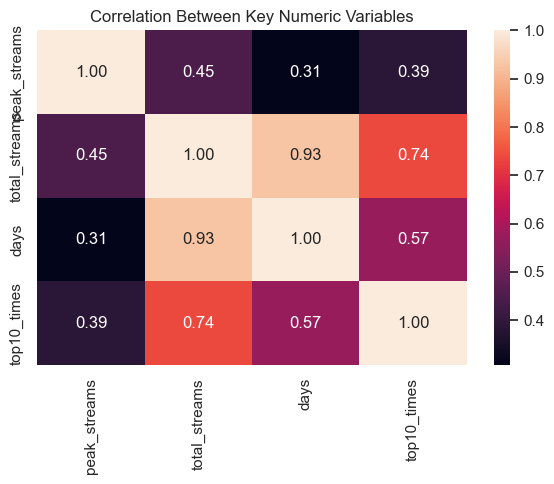

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Between Key Numeric Variables")
plt.tight_layout()
plt.show()

## 4. Simple Modelling – Linear Relationship Between Days and Total Streams

To satisfy the modelling component, I fit a simple linear regression model that predicts 
total streams from the age of a track (days since release). This is not intended to be a 
perfect predictive model, but rather a way to quantify the overall trend observed in the 
scatter plot: older tracks tend to have higher total streams.


In [17]:
model_data = df_clean.dropna(subset=["days", "total_streams"])

x = model_data["days"].values
y = model_data["total_streams"].values

# Fit y = m*x + b
coeffs = np.polyfit(x, y, 1)
slope, intercept = coeffs
y_pred = np.polyval(coeffs, x)

# R^2
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res / ss_tot

slope, intercept, r2

(np.float64(373257.86291990953),
 np.float64(-1610713.7979543856),
 np.float64(0.8609943292111807))

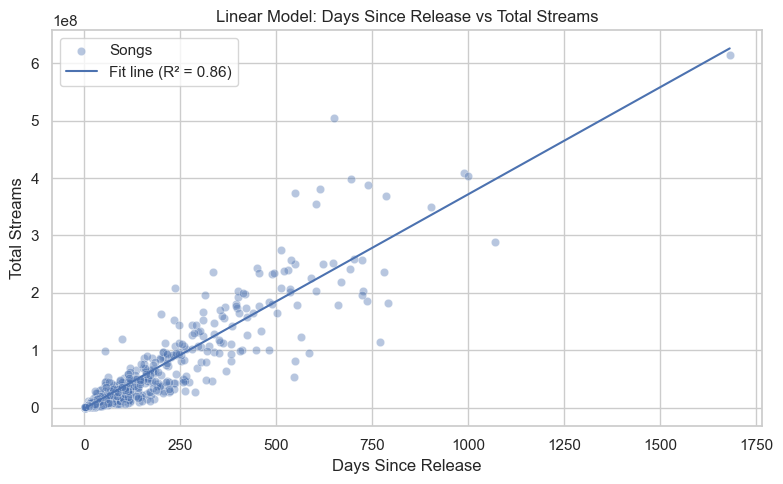

In [18]:
# Plot regression line with a sample of points
sampled = model_data.sample(n=2000, random_state=0) if len(model_data) > 2000 else model_data

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sampled, x="days", y="total_streams", alpha=0.4, label="Songs")
x_line = np.linspace(sampled["days"].min(), sampled["days"].max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, label=f"Fit line (R² = {r2:.2f})")
plt.title("Linear Model: Days Since Release vs Total Streams")
plt.xlabel("Days Since Release")
plt.ylabel("Total Streams")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Discussion

Examining streaming behavior across a wide range of tracks was made possible by the dataset's substantial number of observations.  Following the required cleaning procedures, a number of patterns became apparent.  First, there was a significant skew in the distribution of total streams, with a smaller number of songs reaching exceptionally high totals while the majority of songs achieved moderate streaming levels.  This is consistent with typical media consumption patterns, where a significant portion of total engagement is accounted for by a small number of popular items.

Days since release and total streams were found to be strongly positively correlated. 
As might be expected given their longer exposure time, older songs typically accumulated more streams.  Scatter plots and the correlation matrix, which showed a correlation between days and total streams greater than 0.90, both provided quantitative evidence for this relationship.  This relationship shows that track longevity is a major factor in cumulative streaming volume, even though it is not causal.

A comparatively small number of artists dominate all streams, according to aggregated analyses by artist.  Names like Drake, Post Malone, Juice WRLD, and The Weeknd consistently placed at the top when the total streaming volume was calculated across all of each artist's songs.  This result highlights the dataset's uneven popularity distribution.

Songs with higher peak chart positions generally had better streaming performance, according to the multi-key grouped analysis.  Tracks with a peak ranking of 1 or in the top 5 typically received more streams overall and appeared in the top 10 more frequently. 
The boxplot that compared total streams across peak position categories agreed with this outcome.

I fitted a straightforward linear regression model to measure the correlation between track age and total streams.  Days since release could account for a significant amount of the variation in total streams, according to the model's high R2 value.  The model did, however, also show some exceptions: some older songs continued to have a relatively low level of popularity, while some newer songs quickly accumulated streams.

Overall, the findings imply that a variety of factors, such as track age, chart success, and artist recognition, influence streaming performance.  The analysis reveals the strong correlation between chart behavior and cumulative stream counts as well as the highly skewed nature of streaming outcomes.

## 6. GenAI Disclosure

I supported multiple phases of this assignment with a Large Language Model (ChatGPT). 
While I made all of the final choices regarding the analysis, code, and wording, my use of GenAI was concentrated on interpretation, debugging, language clarity, and high-level review.

**Understanding the assignment and checking dataset suitability**
- I requested assistance from ChatGPT in interpreting the assignment guidelines and grading standards, which included the limitations on dataset size and complexity as well as the necessary components (EDA, grouped tables, modeling, and visualizations).
-  I used ChatGPT to verify that the Spotify streaming dataset I chose was suitable for the task, especially with regard to file size, row and column counts, the presence of both numerical and categorical variables, and the viability of grouping and basic modeling on it.

**Debugging code and resolving errors**
- When I ran into problems with my analysis environment, such as missing packages, kernel selection, and unexpected behavior in Jupyter Notebook cells, I turned to ChatGPT.
- ChatGPT gave me instructions on how to confirm my virtual environment setup, make sure the right kernel was chosen in Visual Studio Code, and see if the notebook was running in the designated working directory.
- I changed my environment paths, reinstalled the necessary libraries, and restarted the notebook cells in order to implement these suggestions.  Following these procedures, the notebook functioned properly and showed all tables and visualizations as anticipated.

**Language and style support as an international student**
- I used ChatGPT as an international student to check the grammar and style of the Introduction, Discussion, and this GenAI Disclosure, among other written sections.  
- My first drafts were given more formal and coherent versions by ChatGPT.  I then revised these recommendations to reflect my own interpretation of the findings and to ensure that the wording appropriately reflected my actions.

**High-level review of completeness**
- I asked ChatGPT to comment on whether my notebook seemed complete in terms of the assignment requirements (e.g., whether it included sufficient EDA, at least two grouping operations, including one multi-key group, three or more visualizations, and a simple model) after completing the main analysis.
-  I verified that all necessary elements were present based on this feedback, and I made a few small changes to the results' structure and explanation.

**Verification and limits of AI assistance**
- I ran every code cell in my own Jupyter Notebook and checked intermediate outputs like plots, grouped results, summary tables, and `head()` to make sure they made sense and matched the data.
-  I didn't use any recommendations involving intricate modeling pipelines, deep learning, tree-based techniques, or synthetic data, nor did I ask ChatGPT to create or alter the dataset itself.
-  All final analyses, interpretations, and code included in this notebook were reviewed and accepted by me.


## 7. References

- **Assignment specification** – CSCI2000U Scientific Data Analysis, Assignment 1  

- **Dataset source**  
  - *https://www.kaggle.com/datasets/rakkesharv/spotify-top-10000-streamed-songs*

- **Python libraries**  
  - pandas documentation: https://pandas.pydata.org/docs/  
  - NumPy documentation: https://numpy.org/doc/  
  - Matplotlib documentation: https://matplotlib.org/stable/  
  - Seaborn documentation: https://seaborn.pydata.org/
